FILES AVAILABLE IN COLAB
['.config', 'wine_dataset', 'wine+quality.zip', 'wine_quality_model_comparison.csv', 'sample_data']

EXTRACTING ZIP FILE
ZIP file extracted successfully!

FILES INSIDE ZIP
wine_dataset/winequality-red.csv
wine_dataset/winequality-white.csv
wine_dataset/winequality.names

Red Wine Dataset Found:
wine_dataset/winequality-red.csv

WINE QUALITY DATASET

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       

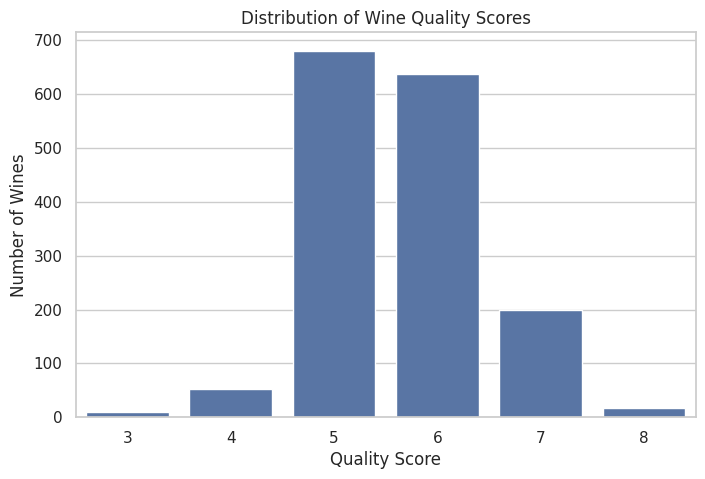


DISTRIBUTION OF CHEMICAL FEATURES


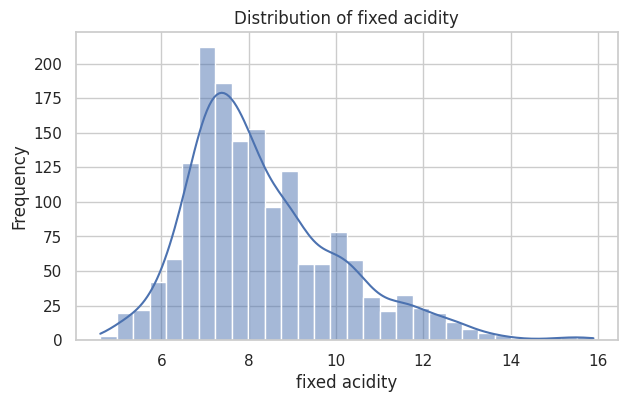

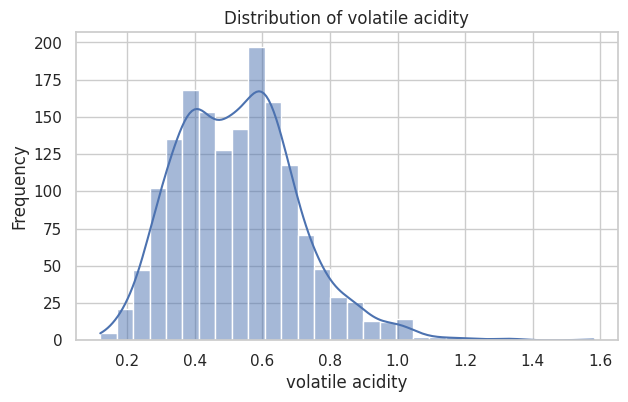

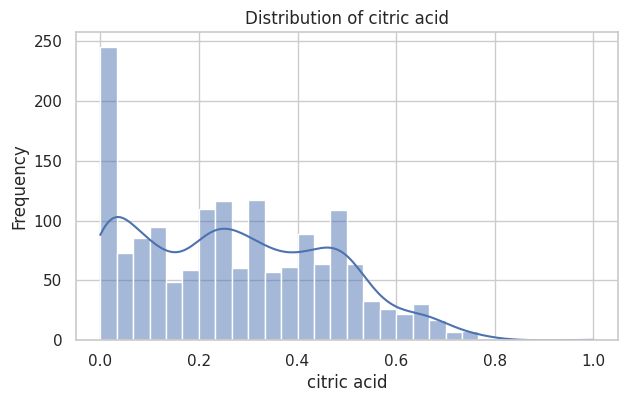

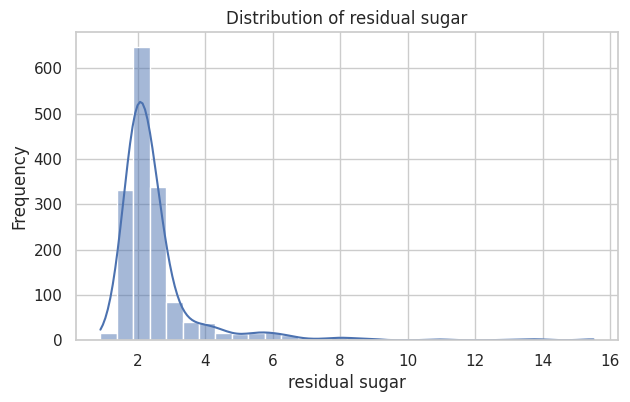

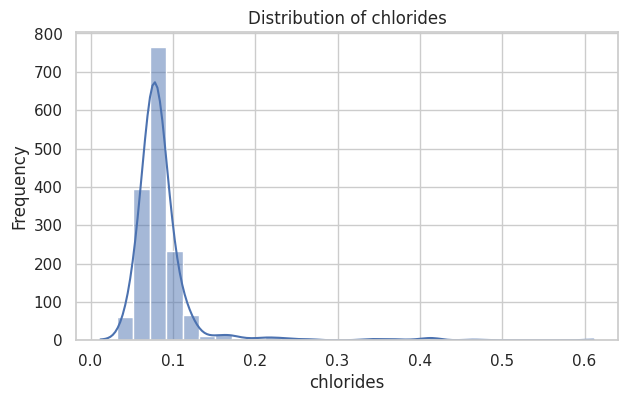

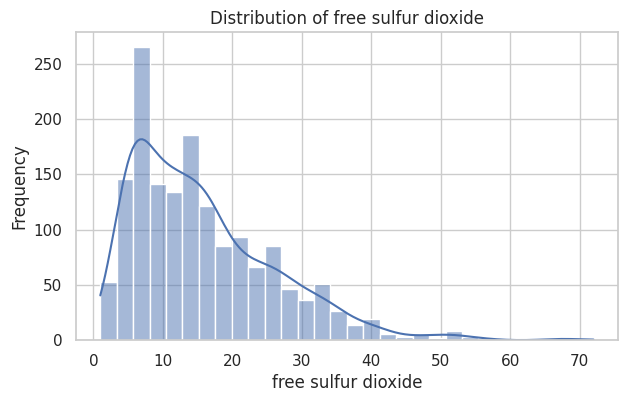

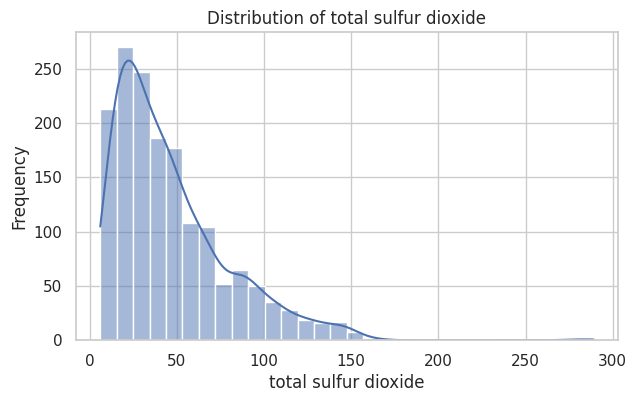

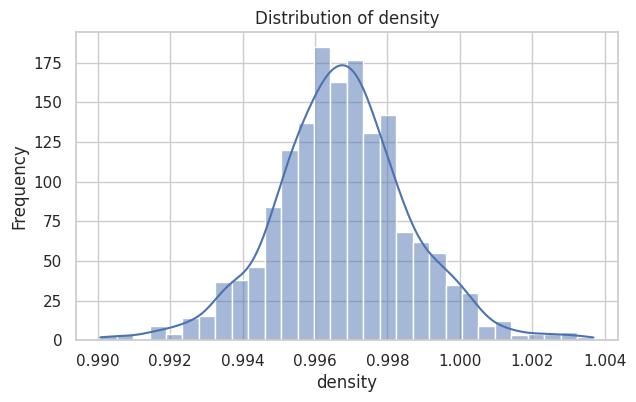

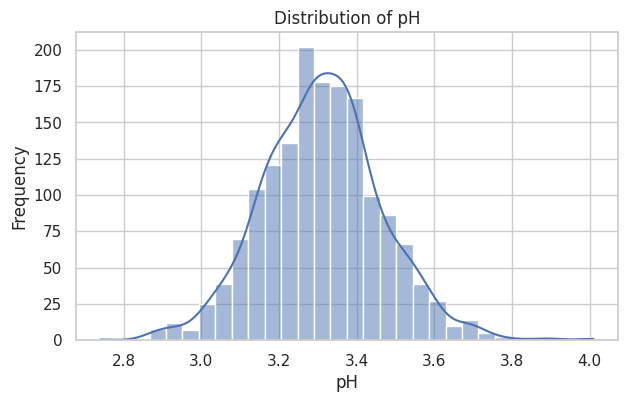

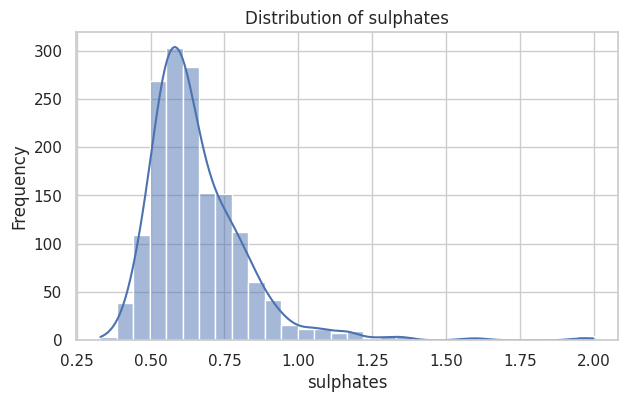

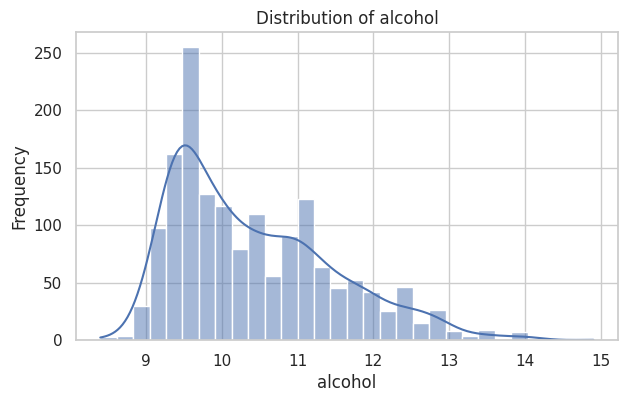


CORRELATION HEATMAP


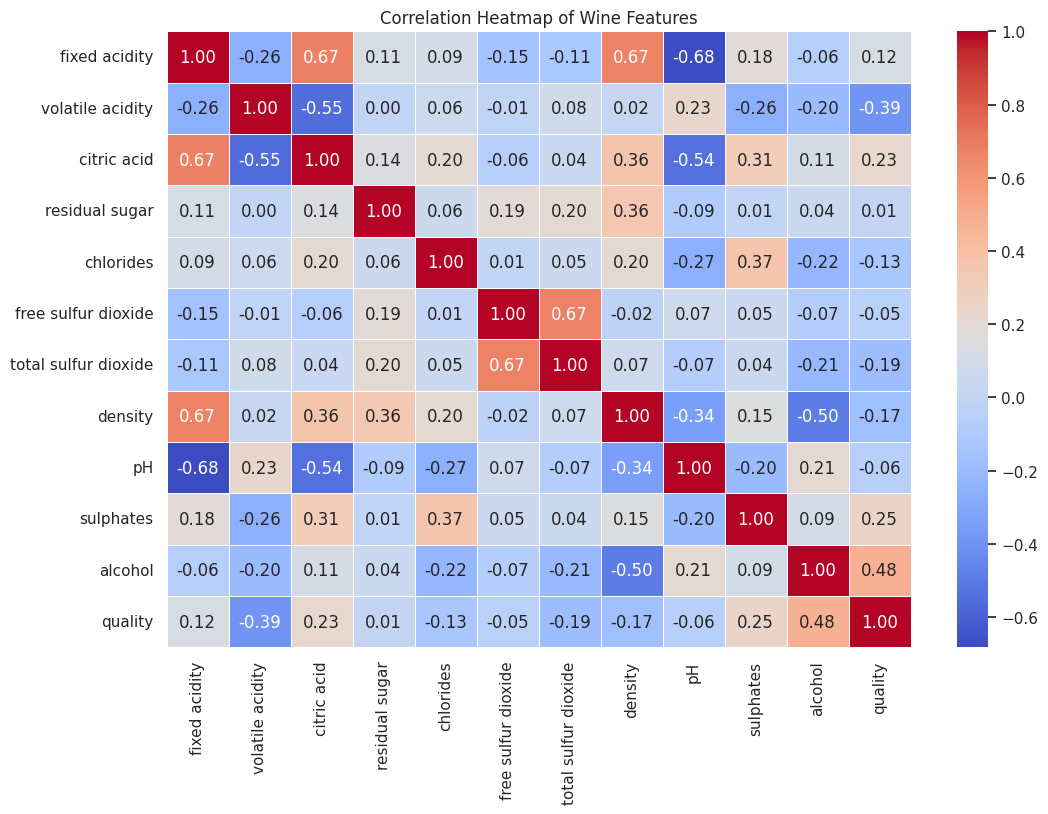


3-CLASS WINE QUALITY DISTRIBUTION
quality_class
Low       744
Medium    638
High      217
Name: count, dtype: int64


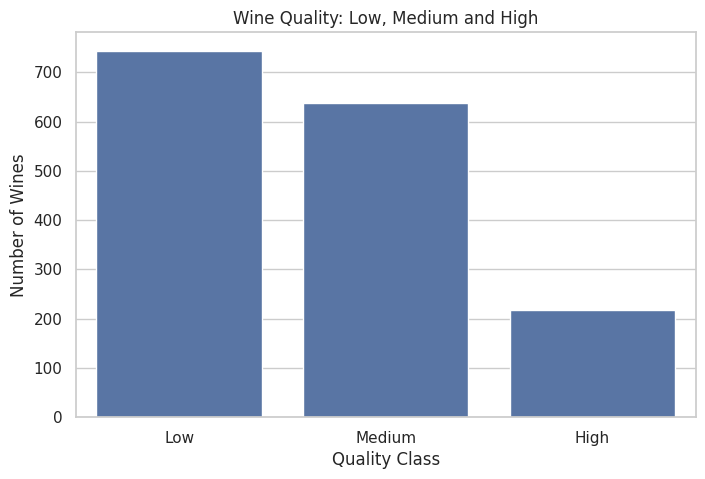


CLASS IMBALANCE DISCUSSION

The original wine quality scores are imbalanced.

Quality scores 5 and 6 have many more samples than very high
quality scores such as 7 and 8.

If we directly predict every individual quality score, the model
may become biased toward the majority classes.

Therefore, the quality scores are grouped into three classes:

Low    : Quality <= 5
Medium : Quality = 6
High   : Quality >= 7

This reduces the number of very small classes and makes the
classification problem easier.

Stratified train-test splitting is used to preserve the class
distribution in both training and testing datasets.

The models also use class_weight='balanced' to reduce the effect
of class imbalance.


FEATURES
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target:
quality_class

TRAIN-TEST SPLIT
Training samples: 1279
Testing samples : 320

Training class distribu

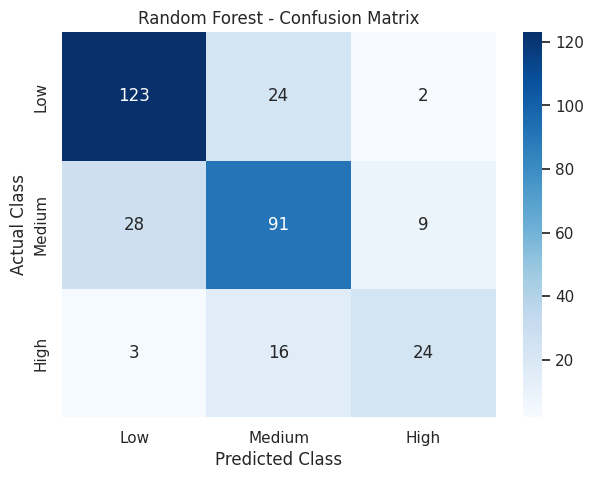

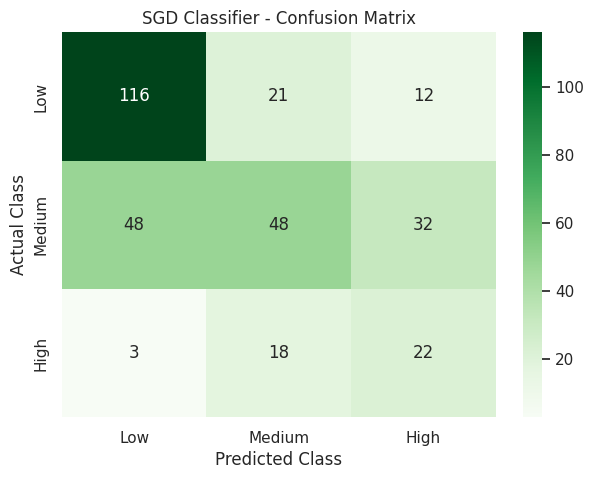

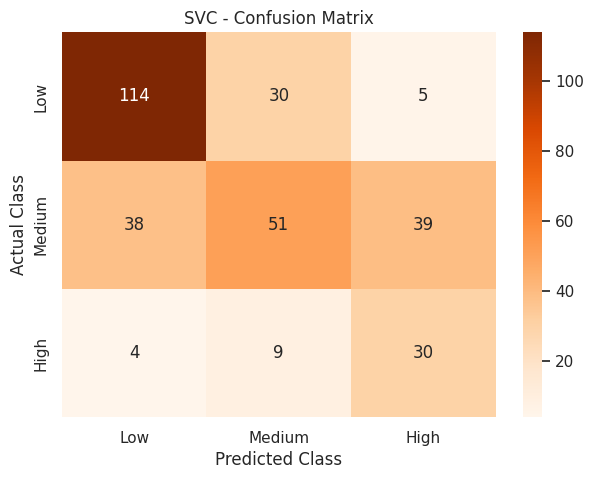


RANDOM FOREST FEATURE IMPORTANCE
                 Feature  Importance
10               alcohol    0.166807
9              sulphates    0.115793
1       volatile acidity    0.110162
6   total sulfur dioxide    0.094225
2            citric acid    0.089683
7                density    0.082704
4              chlorides    0.077093
0          fixed acidity    0.070227
8                     pH    0.067076
3         residual sugar    0.064586
5    free sulfur dioxide    0.061645


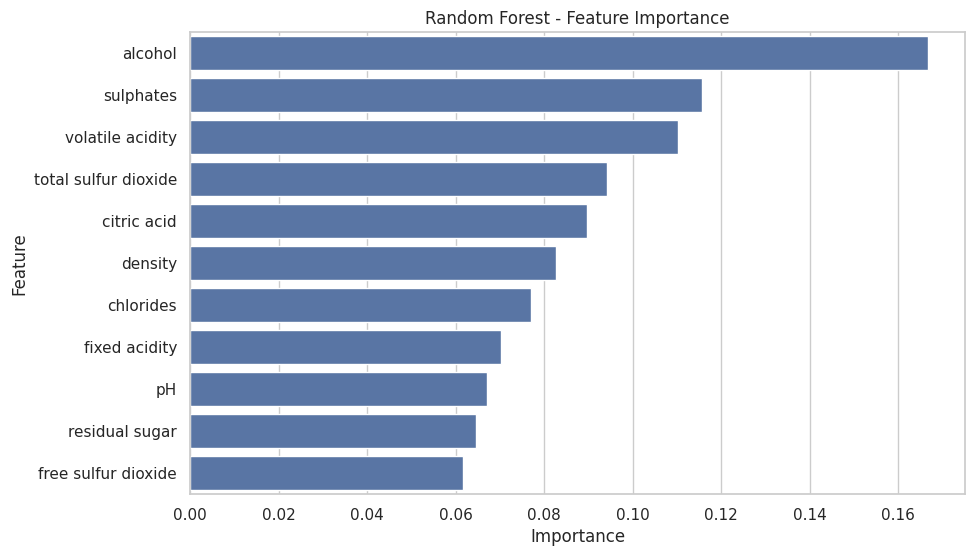


MODEL COMPARISON
         Model  Accuracy  Macro F1  Weighted F1
 Random Forest  0.743750  0.709990     0.741806
           SVC  0.609375  0.576084     0.604140
SGD Classifier  0.581250  0.528120     0.574699

BEST MODEL
Best Model : Random Forest
Accuracy   : 0.7438
Macro F1   : 0.71

FINAL CONCLUSION

Three classification models were trained:

1. Random Forest
2. SGD Classifier
3. Support Vector Classifier (SVC)

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The best model based on Macro F1-score is:

Random Forest

Accuracy:
74.38%

Macro F1-score:
0.7100

Macro F1-score is useful because the wine quality classes are
imbalanced. It gives equal importance to each class.

Therefore, Random Forest is the preferred model for deployment
based on the current test results.


Model comparison saved successfully as:
wine_quality_model_comparison.csv

TASK 2 - WINE QUALITY PREDICTION COMPLETED SUCCESSFULLY


In [5]:


import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")




print("=" * 70)
print("FILES AVAILABLE IN COLAB")
print("=" * 70)

print(os.listdir())



zip_file = "wine+quality.zip"
extract_folder = "wine_dataset"

print("\n" + "=" * 70)
print("EXTRACTING ZIP FILE")
print("=" * 70)

if not os.path.exists(zip_file):
    raise FileNotFoundError(
        f"{zip_file} was not found. Please upload the ZIP file to Colab."
    )

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP file extracted successfully!")




print("\n" + "=" * 70)
print("FILES INSIDE ZIP")
print("=" * 70)

csv_files = []

for root, dirs, files in os.walk(extract_folder):
    for file in files:
        full_path = os.path.join(root, file)
        print(full_path)

        if file.lower().endswith(".csv"):
            csv_files.append(full_path)



red_wine_file = None

for file in csv_files:
    if "red" in os.path.basename(file).lower():
        red_wine_file = file
        break

if red_wine_file is None:
    raise FileNotFoundError(
        "Red wine CSV file was not found inside the ZIP file."
    )

print("\nRed Wine Dataset Found:")
print(red_wine_file)



# UCI Wine Quality CSV uses semicolon (;)
df = pd.read_csv(red_wine_file, sep=";")

print("\n" + "=" * 70)
print("WINE QUALITY DATASET")
print("=" * 70)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())



print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()




print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("\nNo missing values found.")
else:
    print("\nMissing values are present.")



print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

print(df.describe())



print("\n" + "=" * 70)
print("ORIGINAL QUALITY SCORE DISTRIBUTION")
print("=" * 70)

quality_counts = df["quality"].value_counts().sort_index()

print(quality_counts)


# Plot quality distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality"
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()




print("\n" + "=" * 70)
print("DISTRIBUTION OF CHEMICAL FEATURES")
print("=" * 70)

features = df.drop(columns=["quality"]).columns

for column in features:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()



print("\n" + "=" * 70)
print("CORRELATION HEATMAP")
print("=" * 70)

plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Features")
plt.show()




# Low    = quality <= 5
# Medium = quality == 6
# High   = quality >= 7

def quality_category(score):

    if score <= 5:
        return "Low"

    elif score == 6:
        return "Medium"

    else:
        return "High"


df["quality_class"] = df["quality"].apply(quality_category)



print("\n" + "=" * 70)
print("3-CLASS WINE QUALITY DISTRIBUTION")
print("=" * 70)

class_order = ["Low", "Medium", "High"]

class_counts = (
    df["quality_class"]
    .value_counts()
    .reindex(class_order)
)

print(class_counts)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality_class",
    order=class_order
)

plt.title("Wine Quality: Low, Medium and High")
plt.xlabel("Quality Class")
plt.ylabel("Number of Wines")

plt.show()




print("\n" + "=" * 70)
print("CLASS IMBALANCE DISCUSSION")
print("=" * 70)

print("""
The original wine quality scores are imbalanced.

Quality scores 5 and 6 have many more samples than very high
quality scores such as 7 and 8.

If we directly predict every individual quality score, the model
may become biased toward the majority classes.

Therefore, the quality scores are grouped into three classes:

Low    : Quality <= 5
Medium : Quality = 6
High   : Quality >= 7

This reduces the number of very small classes and makes the
classification problem easier.

Stratified train-test splitting is used to preserve the class
distribution in both training and testing datasets.

The models also use class_weight='balanced' to reduce the effect
of class imbalance.
""")



# Remove original quality and new target column
X = df.drop(
    columns=["quality", "quality_class"]
)

y = df["quality_class"]


print("\n" + "=" * 70)
print("FEATURES")
print("=" * 70)

print(X.columns.tolist())

print("\nTarget:")
print("quality_class")



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining class distribution:")
print(
    y_train
    .value_counts()
    .reindex(class_order)
)

print("\nTesting class distribution:")
print(
    y_test
    .value_counts()
    .reindex(class_order)
)




print("\n" + "=" * 70)
print("TRAINING RANDOM FOREST")
print("=" * 70)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_macro_f1 = f1_score(
    y_test,
    rf_pred,
    average="macro"
)

rf_weighted_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("Random Forest training completed.")



print("\n" + "=" * 70)
print("TRAINING SGD CLASSIFIER")
print("=" * 70)

sgd_model = Pipeline([

    ("scaler", StandardScaler()),

    (
        "sgd",
        SGDClassifier(
            loss="log_loss",
            max_iter=2000,
            tol=1e-3,
            random_state=42,
            class_weight="balanced"
        )
    )
])

sgd_model.fit(
    X_train,
    y_train
)

sgd_pred = sgd_model.predict(X_test)

sgd_accuracy = accuracy_score(
    y_test,
    sgd_pred
)

sgd_macro_f1 = f1_score(
    y_test,
    sgd_pred,
    average="macro"
)

sgd_weighted_f1 = f1_score(
    y_test,
    sgd_pred,
    average="weighted"
)

print("SGD Classifier training completed.")




print("\n" + "=" * 70)
print("TRAINING SUPPORT VECTOR CLASSIFIER")
print("=" * 70)

svc_model = Pipeline([

    ("scaler", StandardScaler()),

    (
        "svc",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced"
        )
    )
])

svc_model.fit(
    X_train,
    y_train
)

svc_pred = svc_model.predict(X_test)

svc_accuracy = accuracy_score(
    y_test,
    svc_pred
)

svc_macro_f1 = f1_score(
    y_test,
    svc_pred,
    average="macro"
)

svc_weighted_f1 = f1_score(
    y_test,
    svc_pred,
    average="weighted"
)

print("SVC training completed.")



print("\n" + "=" * 70)
print("RANDOM FOREST - CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        rf_pred,
        labels=class_order,
        zero_division=0
    )
)



print("\n" + "=" * 70)
print("SGD CLASSIFIER - CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        sgd_pred,
        labels=class_order,
        zero_division=0
    )
)




print("\n" + "=" * 70)
print("SVC - CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        svc_pred,
        labels=class_order,
        zero_division=0
    )
)




rf_cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=class_order
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()




sgd_cm = confusion_matrix(
    y_test,
    sgd_pred,
    labels=class_order
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title("SGD Classifier - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()



svc_cm = confusion_matrix(
    y_test,
    svc_pred,
    labels=class_order
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title("SVC - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()




feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\n" + "=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

print(feature_importance)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()




comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "SGD Classifier",
        "SVC"
    ],

    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ],

    "Macro F1": [
        rf_macro_f1,
        sgd_macro_f1,
        svc_macro_f1
    ],

    "Weighted F1": [
        rf_weighted_f1,
        sgd_weighted_f1,
        svc_weighted_f1
    ]
})


comparison = comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    comparison.to_string(index=False)
)



best_model = comparison.iloc[0]["Model"]
best_accuracy = comparison.iloc[0]["Accuracy"]
best_macro_f1 = comparison.iloc[0]["Macro F1"]


print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Best Model :", best_model)
print("Accuracy   :", round(best_accuracy, 4))
print("Macro F1   :", round(best_macro_f1, 4))



print("\n" + "=" * 70)
print("FINAL CONCLUSION")
print("=" * 70)

print(f"""
Three classification models were trained:

1. Random Forest
2. SGD Classifier
3. Support Vector Classifier (SVC)

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The best model based on Macro F1-score is:

{best_model}

Accuracy:
{best_accuracy:.2%}

Macro F1-score:
{best_macro_f1:.4f}

Macro F1-score is useful because the wine quality classes are
imbalanced. It gives equal importance to each class.

Therefore, {best_model} is the preferred model for deployment
based on the current test results.
""")


comparison.to_csv(
    "wine_quality_model_comparison.csv",
    index=False
)

print("\nModel comparison saved successfully as:")
print("wine_quality_model_comparison.csv")


print("\n" + "=" * 70)
print("TASK 2 - WINE QUALITY PREDICTION COMPLETED SUCCESSFULLY")
print("=" * 70)

### Conclusion

In this task, three classification models—Random Forest, SGD Classifier, and Support Vector Classifier (SVC)—were trained to predict wine quality classes based on physicochemical properties.

The original quality scores were imbalanced, so they were grouped into three classes: Low, Medium, and High. Stratified train-test splitting and balanced class weights were used to reduce the effect of class imbalance.

Among the three models, **Random Forest performed the best**, achieving an accuracy of **74.38%** and a Macro F1-score of **0.71**. SVC achieved 60.94% accuracy, while SGD Classifier achieved 58.13%.

The Random Forest feature importance analysis showed that **alcohol, sulphates, volatile acidity, total sulfur dioxide, and citric acid** were among the most important features for predicting wine quality.

Therefore, **Random Forest is the preferred model for deployment** for this dataset because it achieved the highest accuracy and Macro F1-score among the tested models and provided useful feature importance information.
